In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import pickle, scipy.sparse as sp
import warnings; warnings.filterwarnings('ignore')
from sklearn.metrics import (accuracy_score, precision_score,
recall_score, f1_score, roc_auc_score)
print("Ready!")

Ready!


In [2]:
from sklearn.linear_model import LogisticRegression
X_train = sp.load_npz('saved_models/X_train.npz')
X_test = sp.load_npz('saved_models/X_test.npz')
y_train = np.load('saved_models/y_train.npy')
y_test = np.load('saved_models/y_test.npy')
lr_model = pickle.load(open('saved_models/lr_model.pkl','rb'))
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:,1]
lr_results = {
'Model' : 'Logistic Regression',
'Type' : 'ML',
'Accuracy' : accuracy_score(y_test, lr_pred),
'Precision': precision_score(y_test, lr_pred),
'Recall' : recall_score(y_test, lr_pred),
'F1' : f1_score(y_test, lr_pred),
'ROC-AUC' : roc_auc_score(y_test, lr_prob),
}
print("LR results loaded!")

LR results loaded!


In [3]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
df = pd.read_csv('cleaned_data.csv')
tokenizer= pickle.load(open('saved_models/lstm_tokenizer.pkl','rb'))
lstm_model = load_model('saved_models/lstm_model.h5')
sequences = tokenizer.texts_to_sequences(df['clean_text'].astype(str))
X_pad_all = pad_sequences(sequences, maxlen=300, truncating='post')
from sklearn.model_selection import train_test_split
_, X_test_seq, _, y_test_seq = train_test_split(
X_pad_all, df['label'].values,
test_size=0.2, random_state=42, stratify=df['label'])
lstm_prob = lstm_model.predict(X_test_seq).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)
lstm_results = {
'Model' : 'LSTM',
'Type' : 'DL',
'Accuracy' : accuracy_score(y_test_seq, lstm_pred),
'Precision': precision_score(y_test_seq, lstm_pred),
'Recall' : recall_score(y_test_seq, lstm_pred),
'F1' : f1_score(y_test_seq, lstm_pred),
'ROC-AUC' : roc_auc_score(y_test_seq, lstm_prob),
}
print("LSTM results loaded!")

277/277 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step
LSTM results loaded!


In [4]:
results_df = pd.DataFrame([lr_results, lstm_results])
print("=" * 60)
print(" MODEL COMPARISON — HANSAJA (Member 1)")
print("=" * 60)
print(results_df.to_string(index=False))
print("=" * 60)

 MODEL COMPARISON — HANSAJA (Member 1)
              Model Type  Accuracy  Precision   Recall       F1  ROC-AUC
Logistic Regression   ML  0.994347   0.992095 0.996264 0.994175 0.999763
               LSTM   DL  0.963030   0.941124 0.985291 0.962701 0.994448


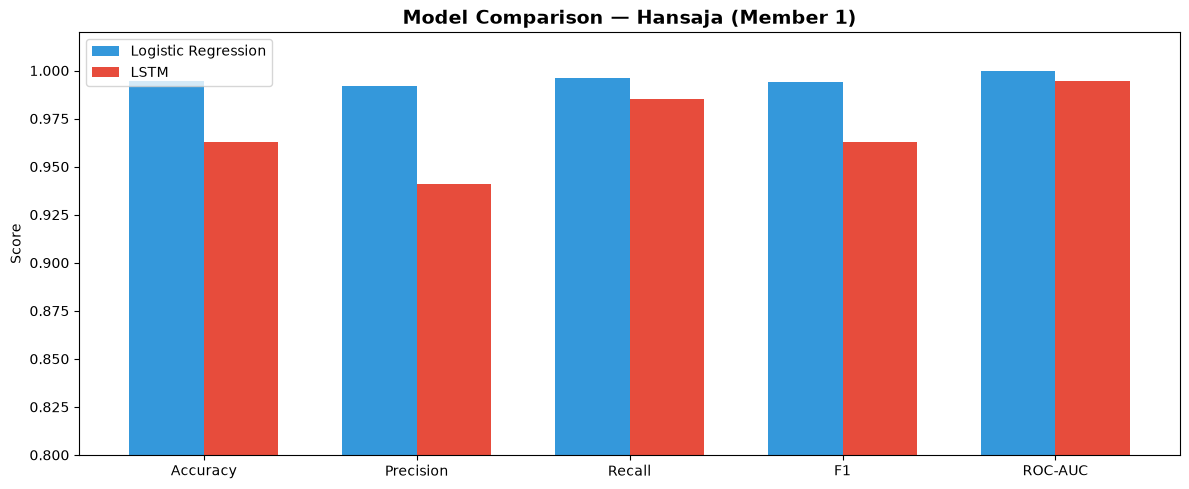

In [5]:
metrics = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics))
width = 0.35
fig, ax = plt.subplots(figsize=(12,5))
bars1 = ax.bar(x - width/2,
[lr_results[m] for m in metrics], width,
label='Logistic Regression', color='#3498db')
bars2 = ax.bar(x + width/2,
[lstm_results[m] for m in metrics], width,
label='LSTM', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.set_title('Model Comparison — Hansaja (Member 1)',
fontsize=14, fontweight='bold')
ax.legend(); ax.set_ylabel('Score')
plt.tight_layout()
plt.savefig('evaluation_comparison.png', dpi=150)
plt.show()

In [6]:
best = max([lr_results, lstm_results], key=lambda x: x['F1'])
print(f"Best Model : {best['Model']}")
print(f"Best F1-Score : {best['F1']:.4f}")
print(f"Best Accuracy : {best['Accuracy']*100:.2f}%")
print()
print("This model will be used in the final Flask application.")

Best Model : Logistic Regression
Best F1-Score : 0.9942
Best Accuracy : 99.43%

This model will be used in the final Flask application.
